
[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Acurácia inicial do modelo: 1.00


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

...

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

Best hyperparameters: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10}


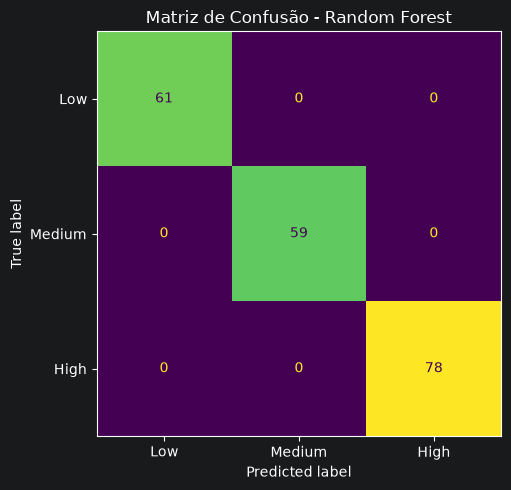

KNN Accuracy: 1.0
KNN Precision: 1.0
KNN Recall: 1.0


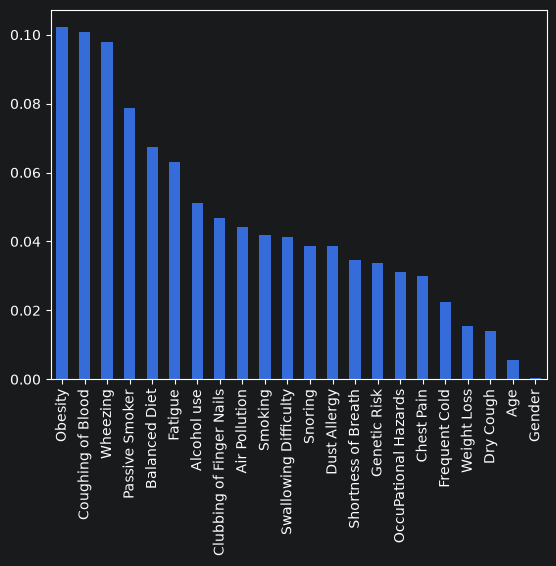

In [9]:
# Data Processing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Tree Visualisation
import sys
!{sys.executable} -m pip install graphviz

import os
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

# 2. Instancie o modelo (definindo o número de vizinhos, ex: n_neighbors=5)
knn = KNeighborsClassifier(n_neighbors=5)

df = pd.read_csv('Dataset(1).csv', index_col='index')
df = df[df['Patient Id'] != '0']
mapa = {'Low': 0, 'Medium': 1, 'High': 2}
df['Level'] = df['Level'].map(mapa)

q1 = df['Age'].quantile(0.25)
q3 = df['Age'].quantile(0.75)
IQR = q3 - q1
lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR
df = df[(df['Age'] >= lower_limit) & (df['Age'] <= upper_limit)]

# 2. Treinamento do Modelo Preditivo
X = df.drop(columns=["Level", "Patient Id", "chronic Lung Disease"]) # Teste
y = df["Level"] # Alvo

# Divide os dados em treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# Treina o modelo inicial
modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_treino, y_treino)

# Avalia o modelo inicial
y_predicao = modelo.predict(X_teste)
acuracia = accuracy_score(y_teste, y_predicao)
print(f"Acurácia inicial do modelo: {acuracia:.2f}")

# Export the first three decision trees from the forest

for i in range(23):
    tree = modelo.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_teste.columns,
                               filled=True,
                               max_depth=4,
                               impurity=False,
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

    parametros = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(modelo,
                                 param_distributions = parametros,
                                 n_iter=5,
                                 cv=5)

# Fit the random search object to the data
rand_search.fit(X_treino, y_treino)

# Create a variable for the best model
best_modelo = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

best_hyperparameters: {'max_depth': 5, 'n_estimators': 260}

# Generate predictions with the best model
y_predicao = best_modelo.predict(X_teste)

# Create the confusion matrix
cm = confusion_matrix(y_teste, y_predicao)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low', 'Medium', 'High']
).plot(ax=ax, colorbar=False)
ax.set_title('Matriz de Confusão - Random Forest')
plt.tight_layout()
plt.savefig('confusão1.png', format='png', dpi=300, bbox_inches='tight')

plt.show()
knn.fit(X_treino, y_treino)
y_predicao_knn = knn.predict(X_teste)

accuracy_knn  = accuracy_score(y_teste, y_predicao_knn)
precision_knn = precision_score(y_teste, y_predicao_knn, average='macro')
recall_knn    = recall_score(y_teste, y_predicao_knn, average='macro')

print("KNN Accuracy:",  accuracy_knn)
print("KNN Precision:", precision_knn)
print("KNN Recall:",    recall_knn)

# Create a series containing feature importances from the model and feature names from the training data
feature_importances = pd.Series(best_modelo.feature_importances_, index=X_treino.columns).sort_values(ascending=False)

# Plot a simple bar chart
feature_importances.plot.bar();

